## Ejercicio Time Series Forecast
Para este ejercicio vamos a predecir cuál será la demanda de pasajeros de una aerolinea, para poder anticiparse a las contrataciones de personal, mantenimiento de las aeronaves y gestión de inventario y comidas.

Para ello, se pide:
1. Carga datos (AirPassengers.csv) y representa la serie. ¿Hay seasonality? ¿Cada cuanto?
2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior. Tienes que usar la función rolling() del DataFrame.
3. Comprueba de manera estadística si la serie es o no stationary.
4. Aplica una transformación logarítmica sobre los datos para mejorar el proceso de transformación de tu time series a stationary. Acuérdate después del forecast de invertir la transformación.
5. Divide en train y test. Guarda 20 muestras para test.
6. Crea tu primer modelo ARIMA. Habrá varias combinaciones en función de sus hiperparámetros... Mide el MAE y RMSE del modelo en predicción. Ten en cuenta el parámetro "m" de la función ARIMA, mediante el cual se establece el seasonality.
7. Representa en una gráfica los datos de test y tus predicciones.
8. Prueba un decission tree y un random forest, a ver qué performance presentan.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## 1. Carga datos y representa la serie

In [3]:
df = pd.read_csv('AirPassengers.csv')

In [4]:
df.head(20)

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
5,1949-06-01,135
6,1949-07-01,148
7,1949-08-01,148
8,1949-09-01,136
9,1949-10-01,119


In [5]:
df.columns


Index(['date', 'value'], dtype='str')

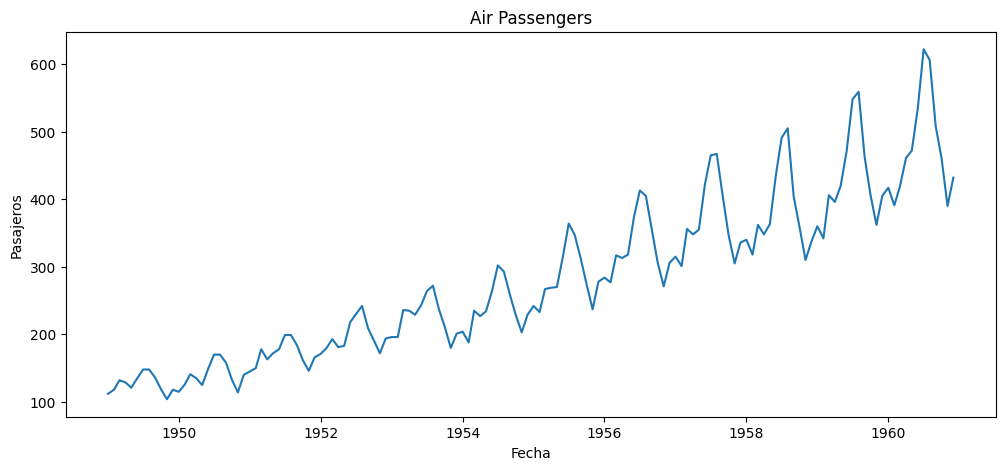

In [6]:
df.columns = ['fecha', 'pasajeros']

df['fecha'] = pd.to_datetime(df['fecha'])

plt.figure(figsize=(12,5))
plt.plot(df['fecha'], df['pasajeros'])

plt.title('Air Passengers')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.show()

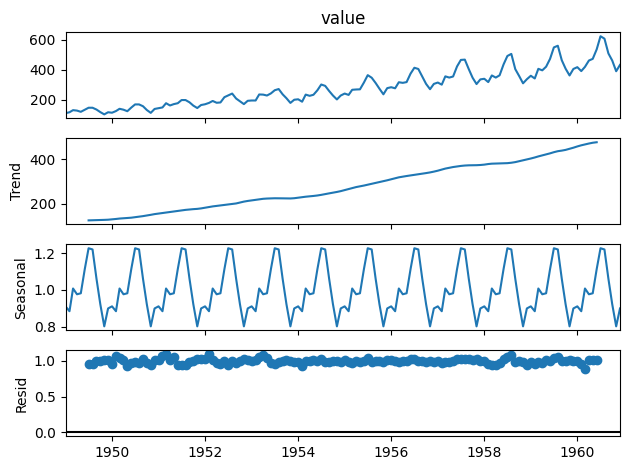

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

df.columns = ['date', 'value']

df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

decomposition = seasonal_decompose(df['value'], model='multiplicative', period=12)

decomposition.plot()
plt.show()

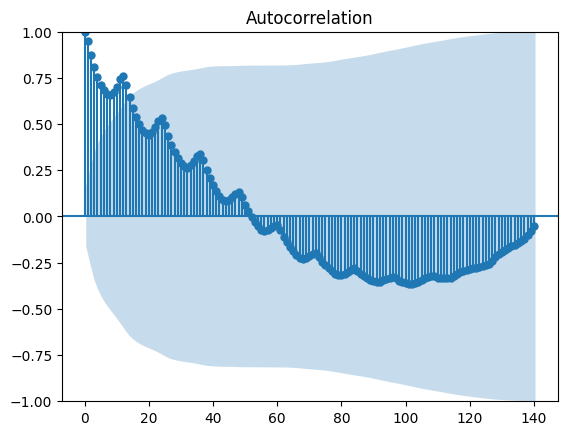

In [8]:
# Pintamos autocorrelación 

from statsmodels.graphics.tsaplots import plot_acf

# Pintamos autocorrelación
plot_acf(df['value'], lags=140)

plt.show()

## 2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior

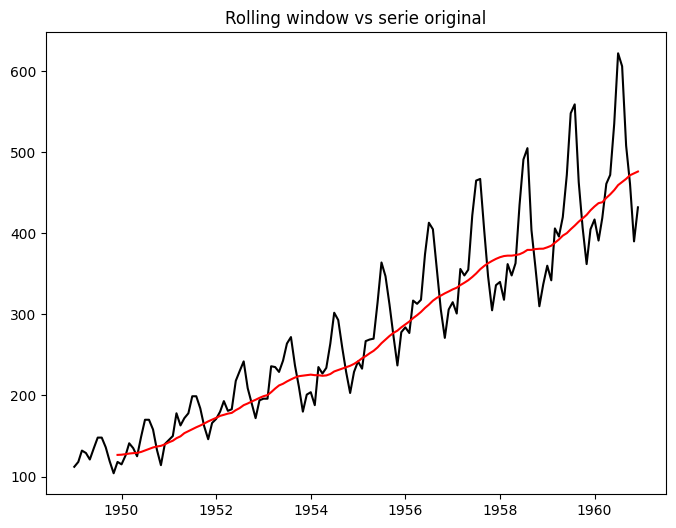

In [9]:
rolling_mean = df['value'].rolling(window=12).mean()

plt.figure(figsize=(8, 6))

plt.plot(df['value'], color='black')
plt.plot(rolling_mean, color='red')

plt.title('Rolling window vs serie original')

plt.show()

## 3. Comprueba de manera estadística si la serie es o no stationary.

El test estadístico es positivo, lo cual implica que es mucho menos probable que rechacemos la hipótesis nula (no estacionaria).

Al comparar el estadístico ADF con los valores críticos, parece que no podríamos rechazar la hipótesis nula de que la serie temporal no es estacionaria y en consecuencia afirmamos que la serie tiene una estructura que sí que es dependiente del tiempo.

Un valor p por encima del umbral sugiere que no rechazamos la hipótesis nula (no estacionario).

In [10]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['value'])

print(f'ADF Statistic: {result[0]:.6f}')
print(f'p-value: {result[1]:.6f}')
print('Critical Values:')

for key, value in result[4].items():
    print(f'\t{key}: {value:.3f}')

ADF Statistic: 0.815369
p-value: 0.991880
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579


#### Conslusión:
Como el p-value es 0.991880 > 0.05, no rechazamos la hipótesis nula. Por tanto, la serie NO es estacionaria.

## 4. Aplica una transformación logarítmica

Podemos ver que el valor es mayor que los valores críticos, lo que significa que podemos rechazar la hipótesis nula y, a su vez, que la serie de tiempo no es estacionaria.

Sin embargo nos sigue interesando aplicar la transformación porque conseguimos estabilizar la varianza.

In [11]:
df_log = np.log(df['value'])

result = adfuller(df_log)

print(f'ADF Statistic: {result[0]:.6f}')
print(f'p-value: {result[1]:.6f}')

for key, value in result[4].items():
    print(f'\t{key}: {value:.3f}')

ADF Statistic: -1.717017
p-value: 0.422367
	1%: -3.482
	5%: -2.884
	10%: -2.579


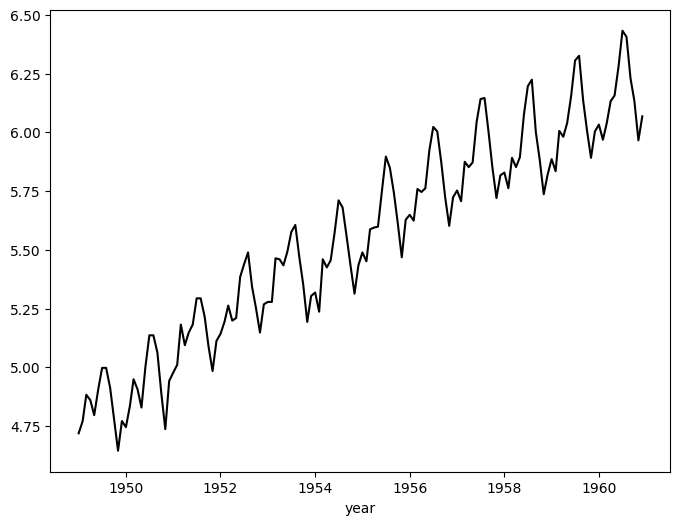

In [12]:
plt.figure(figsize=(8,6))

plt.plot(df.index, df_log, color='black')

plt.xlabel('year')

plt.show()

## 5. Divide en train y test. Guarda 20 muestras para test.

In [13]:
train = df_log[:-20]
test = df_log[-20:]

print(train.shape)
print(test.shape)

(124,)
(20,)


## 6. Crea tu primer modelo ARIMA

In [30]:
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

model = auto_arima(
    train,
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    d=None,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(model.aic())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-201.351, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-202.849, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-204.251, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-202.180, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-208.997, Time=0.08 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.16 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.17 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-204.379, Time=0.04 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-225.739, Time=0.16 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-229.588, Time=0.24 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-229.000, Time=0.18 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=-233.691, Time=0.23 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=-214.822, Time=0.12 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=-232.7

In [32]:
model = auto_arima(train,
                    start_p=1,
                    start_q=1,
                    max_d=3,
                    max_p=5,
                    max_q=5,
                    m=12, 
                    stationary=False,
                    warnings=False,
                    error_action = 'ignore',
                    trace=True,
                   stepwise=True)
print(model.aic())

predictions = model.predict(20)

print("MSE:", mean_squared_error(test.values, predictions))
print("RMSE:", np.sqrt(mean_squared_error(test.values, predictions)))
print("MAE:", mean_absolute_error(test.values, predictions))

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,1,1)[12] intercept   : AIC=-409.584, Time=0.65 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-290.649, Time=0.02 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=-399.417, Time=0.58 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=-353.179, Time=0.26 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=-125.472, Time=0.02 sec
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=-411.631, Time=0.62 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=-384.170, Time=0.11 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=-409.714, Time=1.86 sec
 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=-405.268, Time=0.66 sec
 ARIMA(1,0,1)(1,1,2)[12] intercept   : AIC=-408.108, Time=1.27 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=-408.087, Time=0.29 sec
 ARIMA(2,0,1)(0,1,1)[12] intercept   : AIC=-410.728, Time=0.73 sec
 ARIMA(1,0,2)(0,1,1)[12] intercept   : AIC=-409.956, Time=1.39 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=-300.825, Time=0.13 sec
 ARIMA(0,0,2)(0,1,1

In [33]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  124
Model:             SARIMAX(2, 0, 0)x(0, 1, [1], 12)   Log Likelihood                 211.190
Date:                              Mon, 18 May 2026   AIC                           -412.379
Time:                                      09:57:26   BIC                           -398.787
Sample:                                  01-01-1949   HQIC                          -406.864
                                       - 04-01-1959                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0189      0.010      1.962      0.050    2.23e-05       0.038
ar.L1          0.6085      0.086      7.086      0.000       0.440       0.777
ar.L2          0.2357      0.090      2.625      0.009       0.060       0.412
ma.S.L12      -0.5613      0.116     -4.819      0.000      -0.790      -0.333
sigma2         0.0013      0.000      7.748      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 4.77
Prob(Q):                              0.99   Prob(JB):                         0.09
Heteroskedasticity (H):               0.41   Skew:                             0.09
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.99
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## 7. Representa en una gráfica los datos de test y tus predicciones.

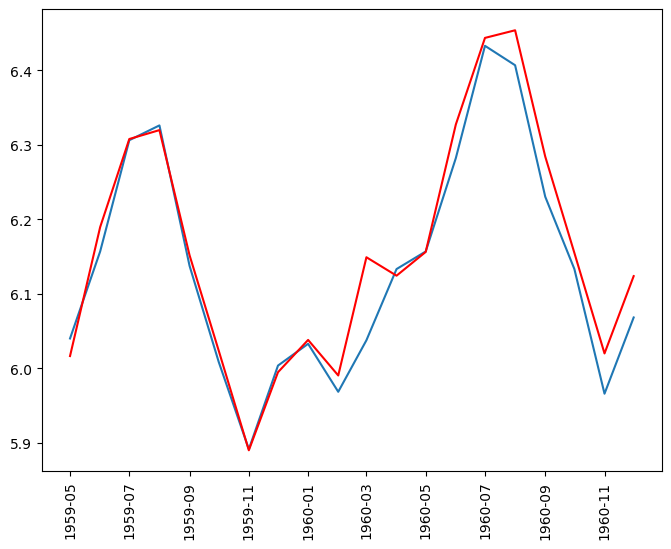

In [34]:
plt.figure(figsize=(8,6))

plt.plot(test.index, test)
plt.plot(test.index, predictions, color='red')

plt.xticks(rotation=90)
plt.show()

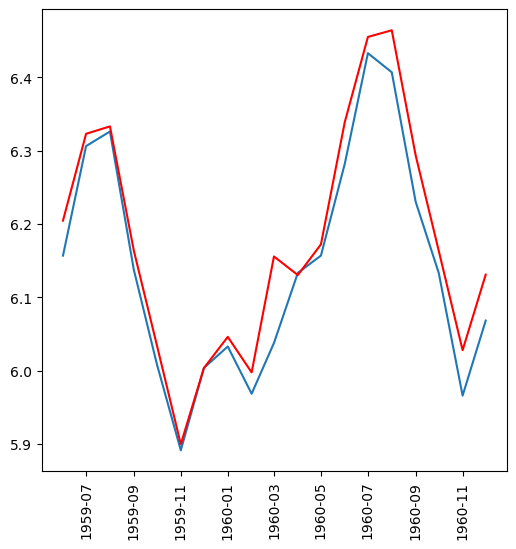

In [35]:
test

date
1959-05-01    6.040255
1959-06-01    6.156979
1959-07-01    6.306275
1959-08-01    6.326149
1959-09-01    6.137727
1959-10-01    6.008813
1959-11-01    5.891644
1959-12-01    6.003887
1960-01-01    6.033086
1960-02-01    5.968708
1960-03-01    6.037871
1960-04-01    6.133398
1960-05-01    6.156979
1960-06-01    6.282267
1960-07-01    6.432940
1960-08-01    6.406880
1960-09-01    6.230481
1960-10-01    6.133398
1960-11-01    5.966147
1960-12-01    6.068426
Name: value, dtype: float64

## 8. Prueba otros modelos, a ver qué performance presentan.

In [36]:

for i in range(12,0,-1):
    df['t-'+str(i)] = df['value'].shift(i) # Cambie el índice por el número deseado de períodos con una frecuencia de tiempo opcional.
df.dropna(inplace=True)

In [37]:
df.head()

,value,t-12,t-11,t-10,t-9,t-8,t-7,t-6,t-5,t-4,t-3,t-2,t-1
date,,,,,,,,,,,,,
1950-01-01,115,112.0,118.0,132.0,129.0,121.0,135.0,148.0,148.0,136.0,119.0,104.0,118.0
1950-02-01,126,118.0,132.0,129.0,121.0,135.0,148.0,148.0,136.0,119.0,104.0,118.0,115.0
1950-03-01,141,132.0,129.0,121.0,135.0,148.0,148.0,136.0,119.0,104.0,118.0,115.0,126.0
1950-04-01,135,129.0,121.0,135.0,148.0,148.0,136.0,119.0,104.0,118.0,115.0,126.0,141.0
1950-05-01,125,121.0,135.0,148.0,148.0,136.0,119.0,104.0,118.0,115.0,126.0,141.0,135.0


In [54]:
# Train y test
train = df_log[:125-12]
test = df_log[125-12:]

predictions = model.predict(n_periods=len(test))
print("Shape train:", train.shape)
print("Shape test:", test.shape)

Shape train: (113,)
Shape test: (31,)


In [57]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

print("MSE:", mean_squared_error(test, predictions))

print("RMSE:", np.sqrt(mean_squared_error(test, predictions)))

print("MAE:", mean_absolute_error(test, predictions))

MSE: 0.03318148152633621
RMSE: 0.1821578478307652
MAE: 0.14449412648741994


In [58]:
y_test_plot = test.values
y_pred_plot = np.array(predictions)

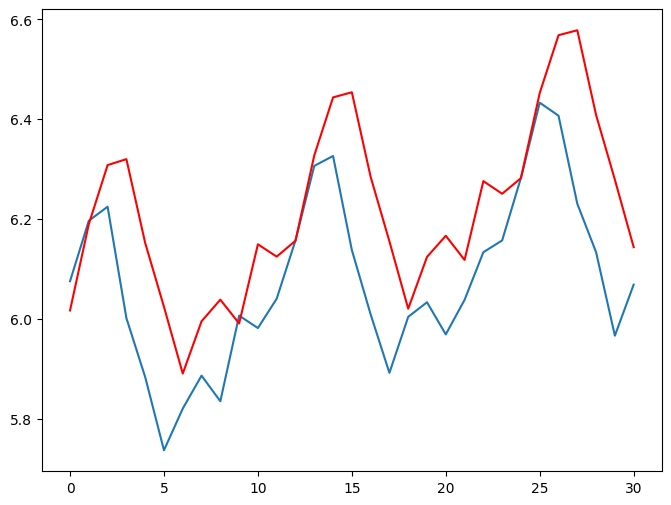

In [60]:
plt.figure(figsize=(8,6))

plt.plot(test.values)
plt.plot(np.array(predictions), color='red')

plt.show()

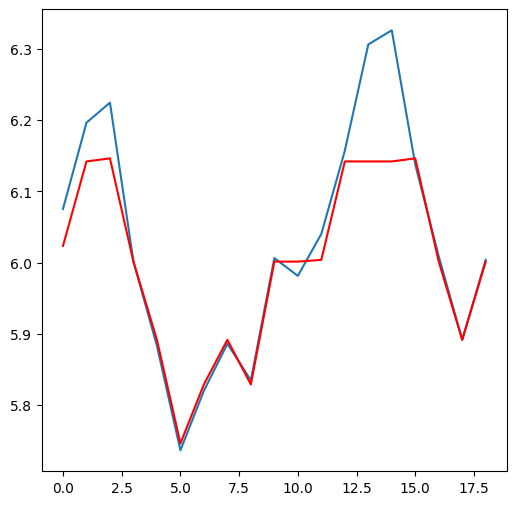